In [17]:
%cd ../..
%env NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="

/home/jj
env: NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from csr.module.utils.notebookutils import NeptuneViewer
pd.options.display.float_format = '{:,.4f}'.format

# 1. Get DataFrame from Neptune project

In [19]:
mapping = {
    'catdog_concepts_convnext_t_signal': 'RRC-Signal',
    'catdog_concepts_convnext_t_svm': 'RRC-SVM',
    'TEM-578': 'CGR_578',
    'TEM-645': 'CGR_645',
    'TEM-646': 'CGR_646',
    'TEM-647': 'CGR_647',
    'TEM-648': 'CGR_648',
    'TEM-654': 'CGR_654',
}

In [20]:
project_name = '240516WaterBrids'

# df = NeptuneViewer.get_neptune_dataframe('smoothAttributionPrior', project_name)

# import os
# os.makedirs('notebooks/results_viewer_wca/exps/Waterbirds', exist_ok=True)
# df.to_csv('notebooks/results_viewer_wca/exps/Waterbirds/240518Waterbirds.csv')
df = pd.read_csv('notebooks/results_viewer/exps/Waterbirds/240518Waterbirds.csv')

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/smoothAttributionPrior/240516WaterBrids/


Fetching table...: 0 [00:00, ?/s]

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/smoothAttributionPrior/240516WaterBrids/metadata


In [21]:

print('-'*20)
print(len(df))

cktp_list = df.query('module_name == "CGR"')['g_ckpt_path'].unique()
for key, module_name in mapping.items():
    try:
        ckpt = [i for i in cktp_list if key in i][0]
    except:
        continue
    idx = df.query('g_ckpt_path == @ckpt').index
    df.loc[idx, 'module_name'] = module_name

--------------------
1248


In [22]:
df['module_name'].value_counts()

module_name
MultiCGR    1152
ERM           48
Name: count, dtype: int64

In [23]:
# df = df.query('module_name == "MultiCGR"')
# `lamb_cs_list` column value is a string, convert it to a list. the column contains two lamb_cs values, and it can be devided by ','. Store them into a new column: `lamb_cs_list_1` and `lamb_cs_list_2`
df['lamb_cs_list'] = df['lamb_cs_list'].apply(lambda x: x.split(','))
df['lamb_cs_list_1'] = df['lamb_cs_list'].apply(lambda x: float(x[0]))
df['lamb_cs_list_2'] = df['lamb_cs_list'].apply(lambda x: float(x[1]))
# delete the `lamb_cs_list` column
df = df.drop(columns=['lamb_cs_list'])


AttributeError: 'float' object has no attribute 'split'

In [ ]:
idx = df['lamb_cs_list_1'] == 0
df.loc[idx, 'module_name'] = 'RRC-Signal'

idx = df['lamb_cs_list_2'] == 0
df.loc[idx, 'module_name'] = 'CGR'

df['module_name'].value_counts()

module_name
CGR           384
MultiCGR      384
RRC-Signal    384
Name: count, dtype: int64

In [ ]:
import os

df_dict = {}
dataset = 'Waterbirds'
module_list = list(df['module_name'].value_counts().index)
for module_name in module_list:
    df_query = df.query('model == "convnext_t" and module_name == @module_name')

    ban_list = ['lr_history', 'data_seed', 'model_path', 'lr_history1', 'data_dir', 'epoch', 'max_epochs']
    var_list = (df_query.nunique() >= 2) & (df_query.nunique() <= 20)
    var_list = [i for i in df.columns[var_list] if 'acc' not in i and i not in ban_list]

    print(module_name, var_list)

    df_query = df_query.sort_values(by=var_list)
    os.makedirs(f'./notebooks/results_viewer/exps/{dataset}/', exist_ok=True)
    df_query.set_index(var_list).to_csv(f'./notebooks/results_viewer/exps/{dataset}/{module_name}.csv')
    df_dict[module_name] = df_query.set_index(var_list)
   
    for var in var_list:
        print(var, df_query[var].unique())
    print()


CGR ['batch_size_train', 'learning_rate', 'minor_ratio', 'lamb_cs_list_1']
batch_size_train [16. 32.]
learning_rate [0.001 0.003]
minor_ratio [0.   0.05]
lamb_cs_list_1 [1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04
 1.e+05 1.e+06 1.e+07 1.e+08 1.e+09 1.e+10]

MultiCGR ['batch_size_train', 'learning_rate', 'minor_ratio', 'lamb_cs_list_1', 'lamb_cs_list_2']
batch_size_train [16. 32.]
learning_rate [0.001 0.003]
minor_ratio [0.   0.05]
lamb_cs_list_1 [1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06]
lamb_cs_list_2 [ 100000. 1000000.]

RRC-Signal ['batch_size_train', 'learning_rate', 'minor_ratio', 'lamb_cs_list_2']
batch_size_train [16. 32.]
learning_rate [0.001 0.003]
minor_ratio [0.   0.05]
lamb_cs_list_2 [3.e+00 1.e+01 3.e+01 1.e+02 3.e+02 1.e+03 3.e+03 1.e+04 3.e+04 1.e+05
 3.e+05 1.e+06 3.e+06 1.e+07 3.e+07 1.e+08]



In [ ]:
def mean_std(x):
    return f'{100*x.mean():.3f}+{100*x.std():.3f}'

def get_best_index(df, var_list, metric):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()
    return idx

def get_mean_with_given_index(df, var_list, metric, idx):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    return df_mean.reset_index().loc[idx].set_index('minor_ratio')[metric]

def get_std_with_given_index(df, var_list, metric, idx):
    df_std = df.groupby(var_list)[metric].std().sort_index()
    return df_std.reset_index().loc[idx].set_index('minor_ratio')[metric]

def sort_and_query(df, sort_by, query):
    df_temp = df.sort_values(by=sort_by)
    df_temp = df_temp.query(query)
    return df_temp

def get_wga(df, module_name):
    df_query = df.query('model == "convnext_t" and module_name == @module_name')

    ban_list = ['lr_history', 'data_seed', 'model_path', 'lr_history1', 'data_dir', 'epoch', 'max_epochs']
    var_list = (df_query.nunique() >= 2) & (df_query.nunique() <= 20)
    var_list = [i for i in df.columns[var_list] if 'acc' not in i and i not in ban_list]

    expected_length = 1
    print(var_list)
    for i in var_list:
        print(i, df_query[i].nunique(), end=', ')
        expected_length *= df_query[i].nunique()
    print()
    print(f'Expected {expected_length}, got {len(df_query)}')

    idx = get_best_index(df_query, var_list, 'valid_valid_best_worst_acc')

    best_mean = get_mean_with_given_index(df_query, var_list, 'test_worst_acc', idx)
    best_std = get_std_with_given_index(df_query, var_list, 'test_worst_acc', idx)
    test_acc_mean = get_mean_with_given_index(df_query, var_list, 'test_acc', idx)
    test_acc_std = get_std_with_given_index(df_query, var_list, 'test_acc', idx)

    return best_mean, best_std, test_acc_mean, test_acc_std

['batch_size_train', 'learning_rate', 'minor_ratio', 'lamb_cs_list_1']
batch_size_train 2, learning_rate 2, minor_ratio 2, lamb_cs_list_1 16, 
Expected 128, got 384
['batch_size_train', 'learning_rate', 'minor_ratio', 'lamb_cs_list_1', 'lamb_cs_list_2']
batch_size_train 2, learning_rate 2, minor_ratio 2, lamb_cs_list_1 8, lamb_cs_list_2 2, 
Expected 128, got 384
['batch_size_train', 'learning_rate', 'minor_ratio', 'lamb_cs_list_2']
batch_size_train 2, learning_rate 2, minor_ratio 2, lamb_cs_list_2 16, 
Expected 128, got 384


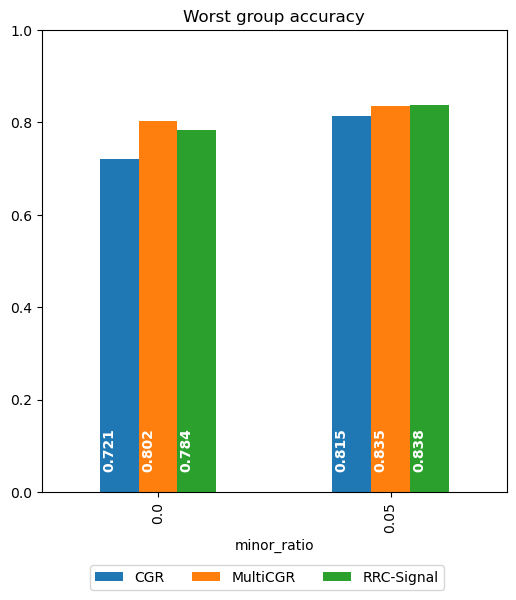

In [ ]:
module_list = df['module_name'].unique()

# get best_mean std and plot
best_mean_list = []
best_std_list = []
test_mean_list = []
test_std_list = [] 
for module_name in module_list:
    best_mean, best_std, test_acc_mean, test_acc_std = get_wga(df, module_name)
    best_mean_list.append(best_mean)
    best_std_list.append(best_std)
    test_mean_list.append(test_acc_mean)
    test_std_list.append(test_acc_std)

fig, ax = plt.subplots(1,1, figsize=(6,6))

best_model_mean = pd.concat(best_mean_list, axis=1)
best_model_mean.columns = module_list

# plot best model mean
bars = best_model_mean.plot(kind='bar', yerr=pd.concat(best_std_list, axis=1), ax=ax, capsize=5, legend=False, ylim=(0, 1))
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=5)
ax.set_title('Worst group accuracy')

for i, vs in enumerate(best_model_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.24 + j * (0.5/len(module_list)) , 0.05, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)


plt.savefig('notebooks/results_viewer/figure/waterbirds_wga.png', bbox_inches='tight')
plt.show()

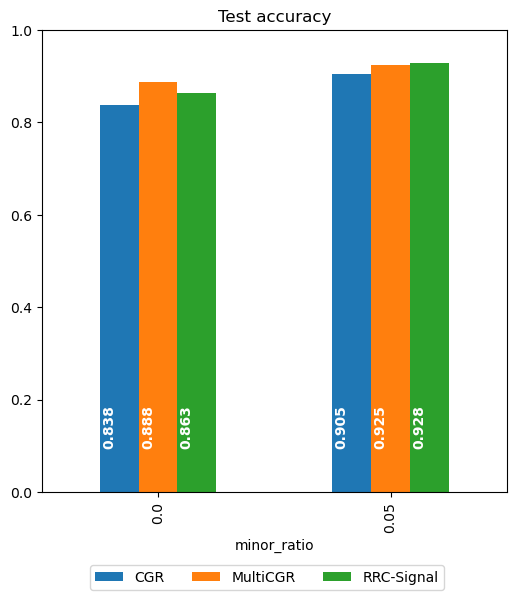

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,6))

test_mean = pd.concat(test_mean_list, axis=1)
test_mean.columns = module_list

# plot best model mean
bars = test_mean.plot(kind='bar', yerr=pd.concat(test_std_list, axis=1), ax=ax, capsize=5, legend=False, ylim=(0, 1))
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=5)
ax.set_title('Test accuracy')


for i, vs in enumerate(test_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.24 + j * (0.5/len(module_list)) , 0.1, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)


plt.savefig('notebooks/results_viewer/figure/waterbirds_ta.png', bbox_inches='tight')
plt.show()

# Lmabda - WGA graph

In [ ]:
def plot_lambda_wga_graph(df, ax, metric, var_list, x_label):
    df = df.groupby(var_list+[x_label])[metric].mean().reset_index().sort_values(by=x_label)
    df = df.groupby(var_list)
    for name, group in df:
        ax.plot(group[x_label], group[metric], label=name)
    ax.legend()
    ax.set_xlabel(x_label)
    ax.set_xscale('log')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs {x_label}')


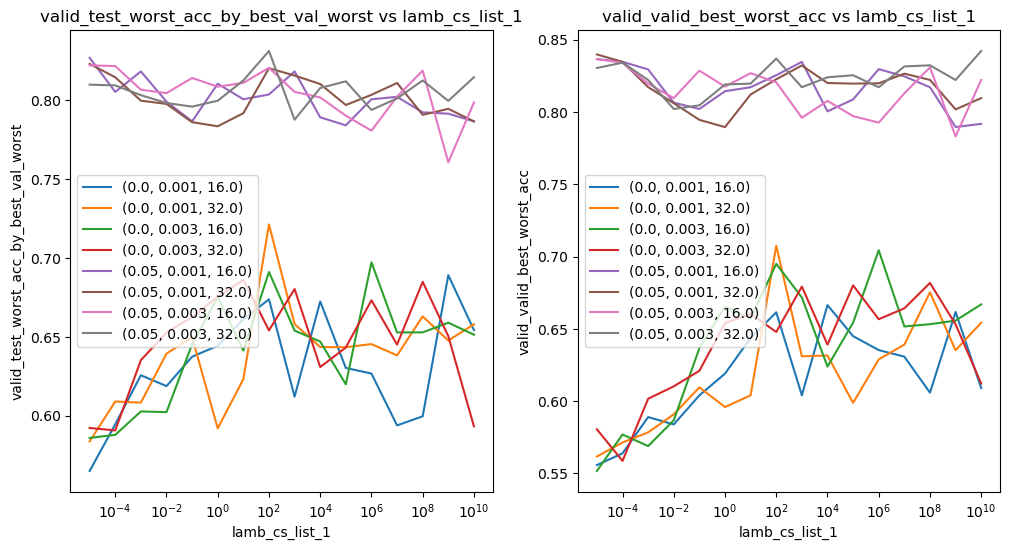

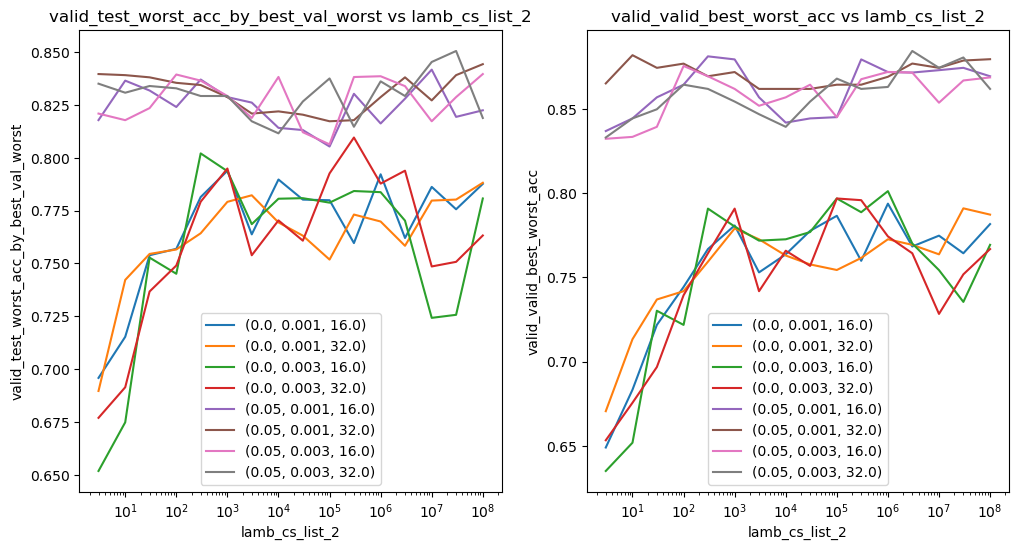

In [ ]:
var_list = ['minor_ratio', 'learning_rate', 'batch_size_train']

# plot
fig, axes = plt.subplots(1,2, figsize=(12,6))

df_temp = df.query('module_name == "CGR"')
plot_lambda_wga_graph(df_temp, axes[0], 'valid_test_worst_acc_by_best_val_worst', var_list, 'lamb_cs_list_1')
plot_lambda_wga_graph(df_temp, axes[1], 'valid_valid_best_worst_acc', var_list, 'lamb_cs_list_1')

fig, axes = plt.subplots(1,2, figsize=(12,6))

df_temp = df.query('module_name == "RRC-Signal"')
plot_lambda_wga_graph(df_temp, axes[0], 'valid_test_worst_acc_by_best_val_worst', var_list, 'lamb_cs_list_2')
plot_lambda_wga_graph(df_temp, axes[1], 'valid_valid_best_worst_acc', var_list, 'lamb_cs_list_2')